In [2]:
library(rhdf5)
library(data.table)
library(ggplot2)
library(LeyLabRMisc)

Warning message:
“replacing previous import ‘data.table::last’ by ‘tidytable::last’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘tidytable::first’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘tidytable::between’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::%notin%’ by ‘tidytable::%notin%’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::fread’ by ‘tidytable::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::fread’ by ‘data.table::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::distinct’ by ‘dplyr::distinct’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::filter’ by ‘dplyr::filter’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::mutate’ by ‘dplyr::mutate’ w

# Contacts profile

In [3]:
get_profile <- function(
  h5file,
  chrX,
  chrY
) {
  library(rhdf5)
  library(data.table)

  # ---- Read intervals ----
  chr   <- h5read(h5file, "intervals/chr_list")
  start <- h5read(h5file, "intervals/start_list")
  end   <- h5read(h5file, "intervals/end_list")

  bins <- data.table(
    bin   = seq_along(chr) - 1,  # 0-based
    chr   = chr,
    start = start,
    end   = end
  )

  bins_X <- bins[chr == chrX, bin]
  bins_Y <- bins[chr == chrY, bin]

  if (length(bins_X) == 0 || length(bins_Y) == 0) {
    stop("One of the chromosomes has no bins in the matrix.")
  }

  # ---- Read sparse matrix ----
  data    <- h5read(h5file, "matrix/data")
  indices <- h5read(h5file, "matrix/indices")
  indptr  <- h5read(h5file, "matrix/indptr")

  # ---- Initialize signal ----
  signal_Y <- setNames(numeric(length(bins_Y)), bins_Y)

  # ---- Symmetry-aware accumulation ----
  for (i in seq_len(length(indptr) - 1) - 1) {

    row_start <- indptr[i + 1] + 1
    row_end   <- indptr[i + 2]

    if (row_start > row_end) next

    cols <- indices[row_start:row_end]
    vals <- data[row_start:row_end]

    # Case 1: row in X, col in Y
    if (i %in% bins_X) {
      keep <- cols %in% bins_Y
      if (any(keep)) {
        signal_Y[as.character(cols[keep])] <-
          signal_Y[as.character(cols[keep])] + vals[keep]
      }
    }

    # Case 2: row in Y, col in X (mirror)
    if (i %in% bins_Y) {
      keep <- cols %in% bins_X
      if (any(keep)) {
        signal_Y[as.character(i)] <-
          signal_Y[as.character(i)] + sum(vals[keep])
      }
    }
  }

  # ---- Output table ----
  out <- bins[bin %in% bins_Y]
  out[, contacts := signal_Y[as.character(bin)]]

  out[, contacts_norm := contacts / length(bins_X)]

  return(out[])
}

In [4]:
# Specify file and sequences to plot
h5_file = "/ebio/abt3_projects2/microc_metagenomics/out/hicexplorer/Mock_final/5000b/contact_matrix_corrected.h5"
chrX <- "P_nigrescens_chr2"
chrX_name <- "chrom2"
chrY <- "P_nigrescens_chr1"
chrY_name <- "chrom1"

In [5]:
profile_XY <- get_profile(h5_file, chrX, chrY)
profile_YX <- get_profile(h5_file, chrY, chrX)

# ~12.5% of each chromosome's bins
profile_XY[, contacts_smooth := frollmean(contacts_norm, n = round(nrow(profile_XY) * 0.125), align = "center", na.rm = TRUE)]
profile_YX[, contacts_smooth := frollmean(contacts_norm, n = round(nrow(profile_YX) * 0.125), align = "center", na.rm = TRUE)]

In [6]:
#Check that the sum of the contacts is the same for both profiles
sum(profile_XY$contacts)
sum(profile_YX$contacts)

[1] 2274033

[1] 2274033

Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


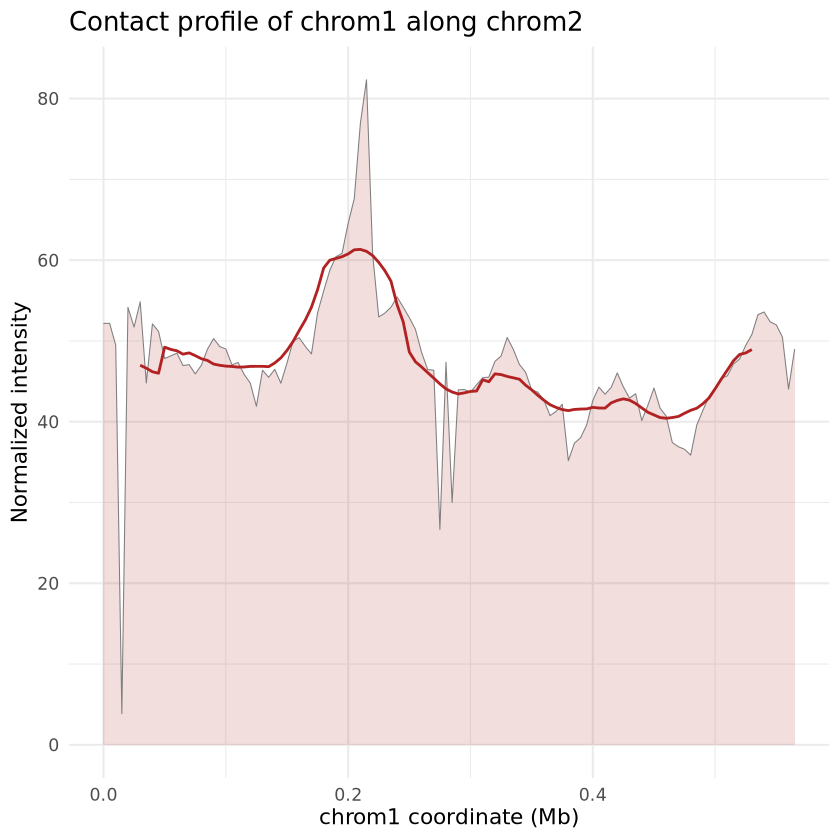

In [7]:
#profile_XY[, contacts_smooth := frollmean(contacts_norm, n = 10, align = "center", na.rm = TRUE)]
profile_XY[, contacts_smooth := frollmean(contacts_norm, n = round(nrow(profile_XY) * 0.125), align = "center", na.rm = TRUE)]

# Plot the contacts of every region in chrY (X axis) against chrX (Y axis)
profile_XY[, pos_Mb := start / 1e6]

thr <- mean(profile_XY$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_XY$end - profile_XY$start) / 1e3

ggplot(profile_XY, aes(x = pos_Mb)) +
  geom_ribbon(aes(ymin = 0, ymax = contacts_norm), fill = "firebrick", alpha = 0.15) +
  geom_line(aes(y = contacts_norm), linewidth = 0.3, color = "grey50") +
  geom_line(aes(y = contacts_smooth), linewidth = 0.8, color = "firebrick") +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrY_name, "along", chrX_name),
    #x = paste(chrY_name, "coordinate (bases)"),
    x = paste(chrY_name, "coordinate (Mb)"),
    y = "Normalized intensity"
    #y = paste("Contacts with", chrX_name),
    #subtitle = paste("Resolution:", bin_size_kb, "kb")
  )

Warning message:
“Removed 52 rows containing missing values or values outside the scale range
(`geom_line()`).”


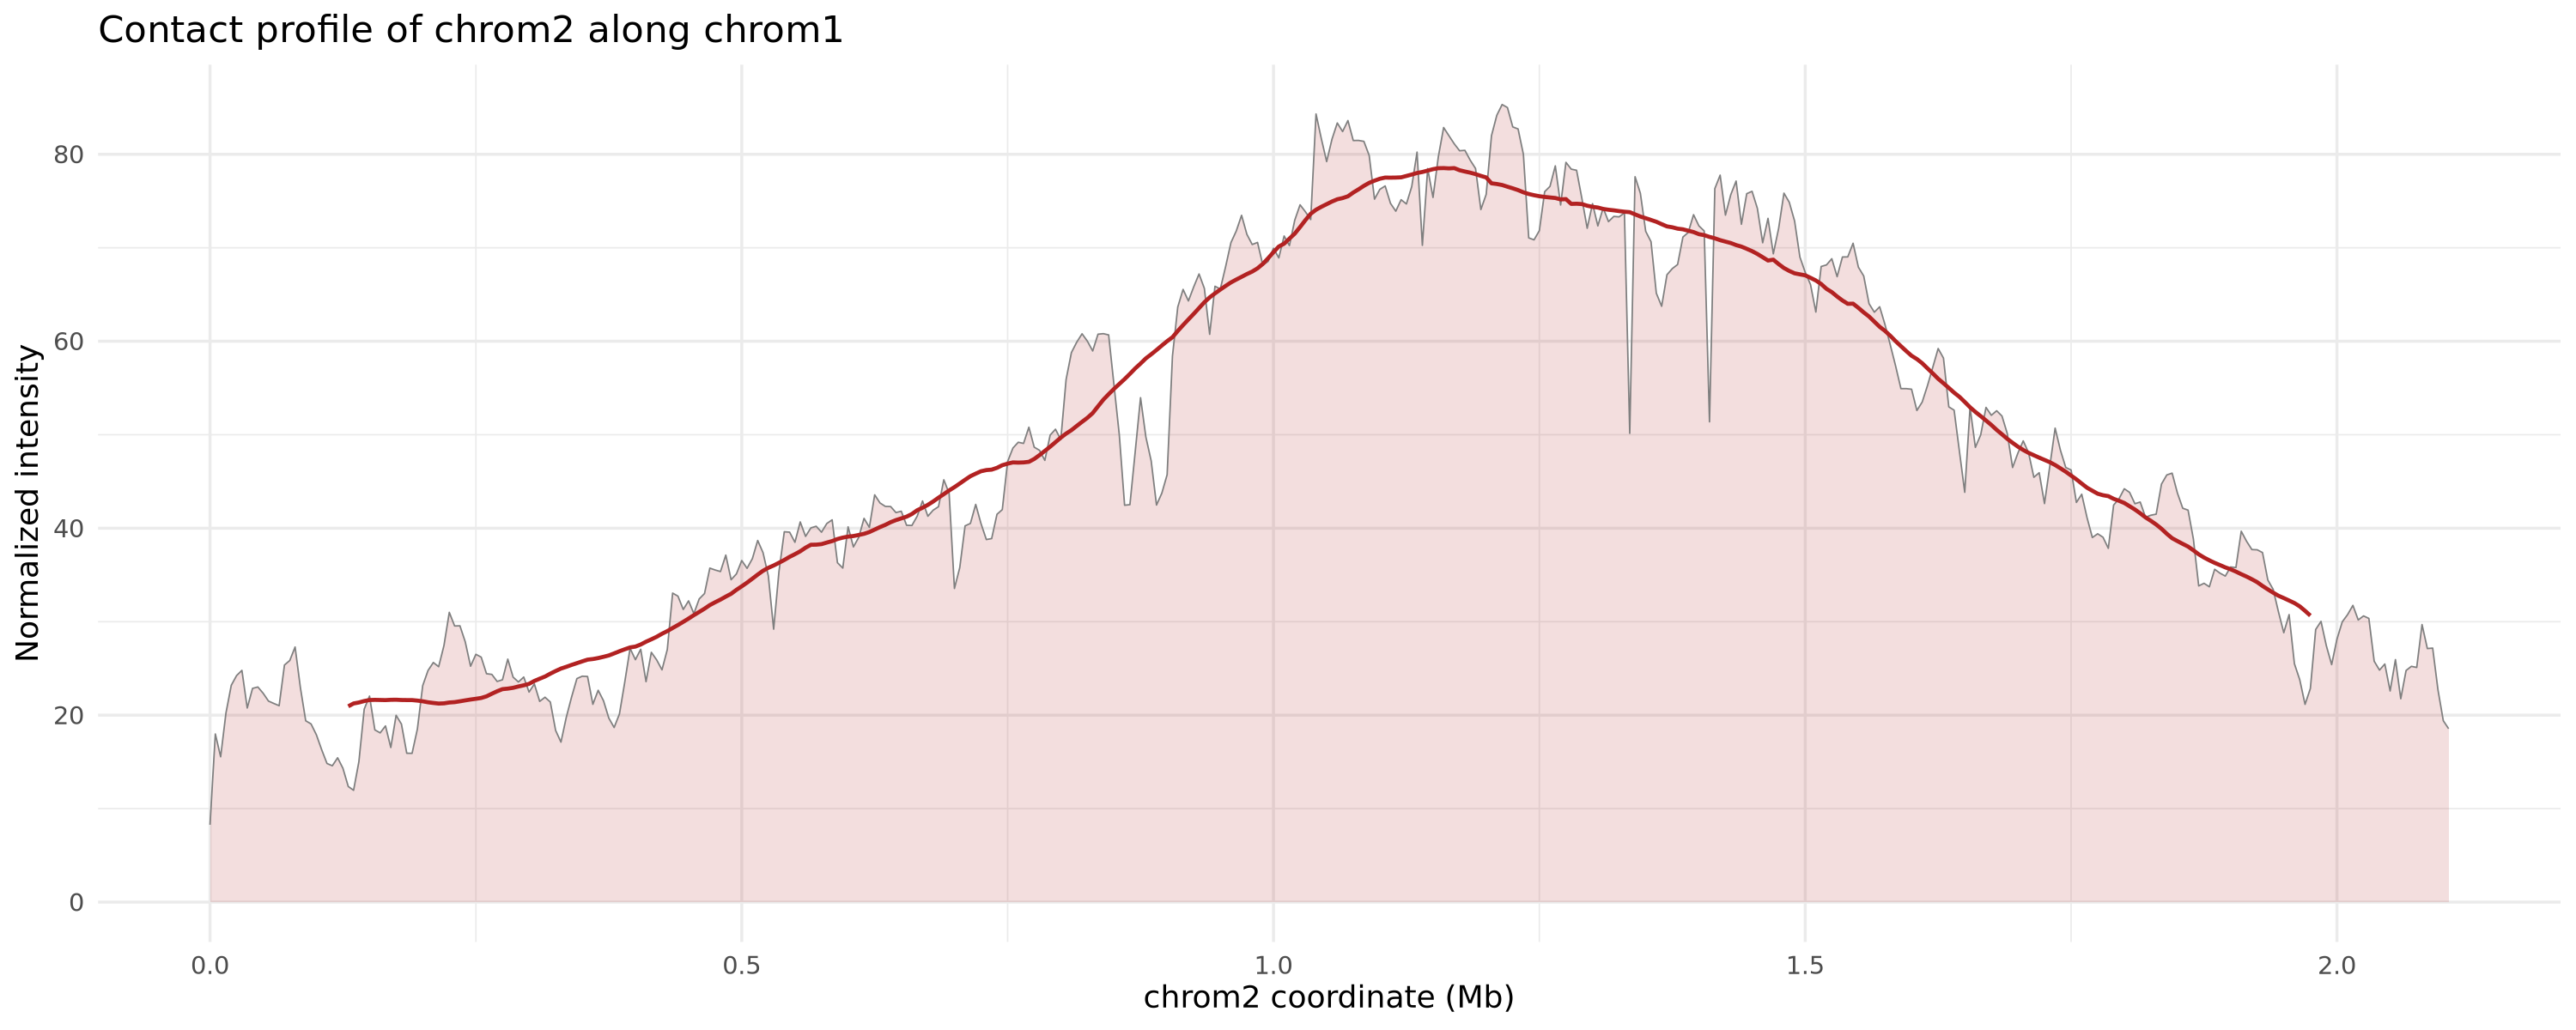

In [8]:
p.dims(15,6)
# Plot the contacts of every region in chrX (X axis) against chrY (Y axis)
profile_YX[, pos_Mb := start / 1e6]

thr <- mean(profile_YX$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_YX$end - profile_YX$start) / 1e3

#ggplot(profile_YX, aes(x = start, y = contacts)) +
ggplot(profile_YX, aes(x = pos_Mb, y = contacts_norm)) +
  geom_ribbon(aes(ymin = 0, ymax = contacts_norm), fill = "firebrick", alpha = 0.15) +
  geom_line(aes(y = contacts_norm), linewidth = 0.3, color = "grey50") +
  geom_line(aes(y = contacts_smooth), linewidth = 0.8, color = "firebrick") +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrX_name, "along", chrY_name),
    #x = paste(chrY_name, "coordinate (bases)"),
    x = paste(chrX_name, "coordinate (Mb)"),
    y = "Normalized intensity"
    #y = paste("Contacts with", chrX_name),
    #subtitle = paste("Resolution:", bin_size_kb, "kb")
  )

`geom_smooth()` using formula = 'y ~ x'


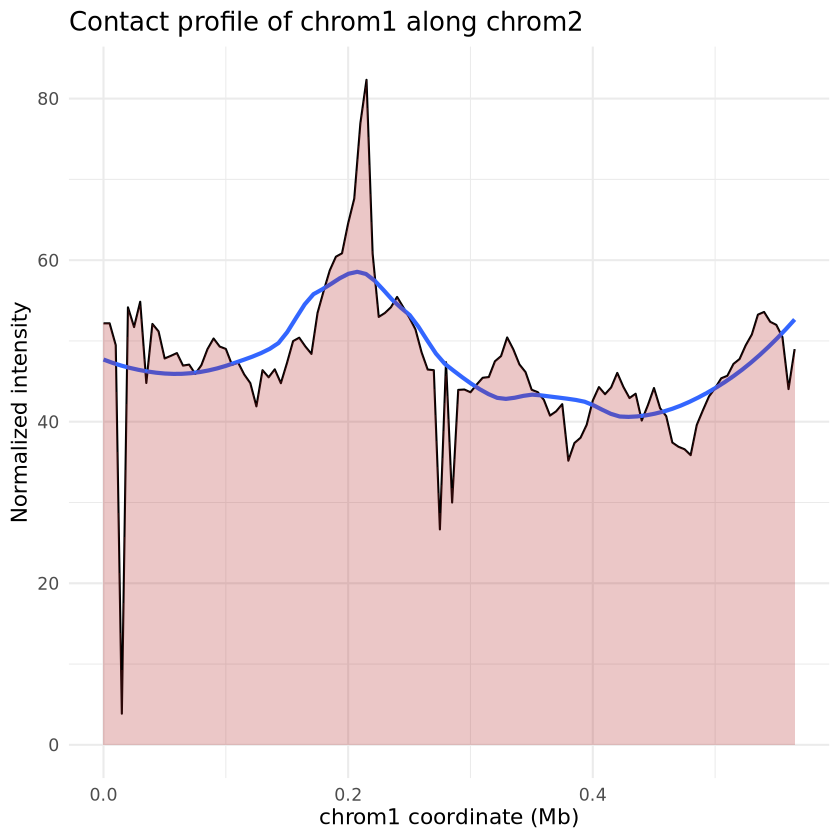

In [6]:
# Plot the contacts of every region in chrY (X axis) against chrX (Y axis)
profile_XY[, pos_Mb := start / 1e6]

thr <- mean(profile_XY$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_XY$end - profile_XY$start) / 1e3

#ggplot(profile_XY, aes(x = start, y = contacts)) +
ggplot(profile_XY, aes(x = pos_Mb, y = contacts_norm)) +
  geom_line(linewidth = 0.6) +
  geom_smooth(method = "loess", span = 0.5, se = FALSE) +
  geom_ribbon(
    aes(ymin = 0, ymax = contacts_norm),
    fill = "firebrick",
    alpha = 0.25
  ) +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrY_name, "along", chrX_name),
    #x = paste(chrY_name, "coordinate (bases)"),
    x = paste(chrY_name, "coordinate (Mb)"),
    y = "Normalized intensity"
    #y = paste("Contacts with", chrX_name),
    #subtitle = paste("Resolution:", bin_size_kb, "kb")
  )

`geom_smooth()` using formula = 'y ~ x'


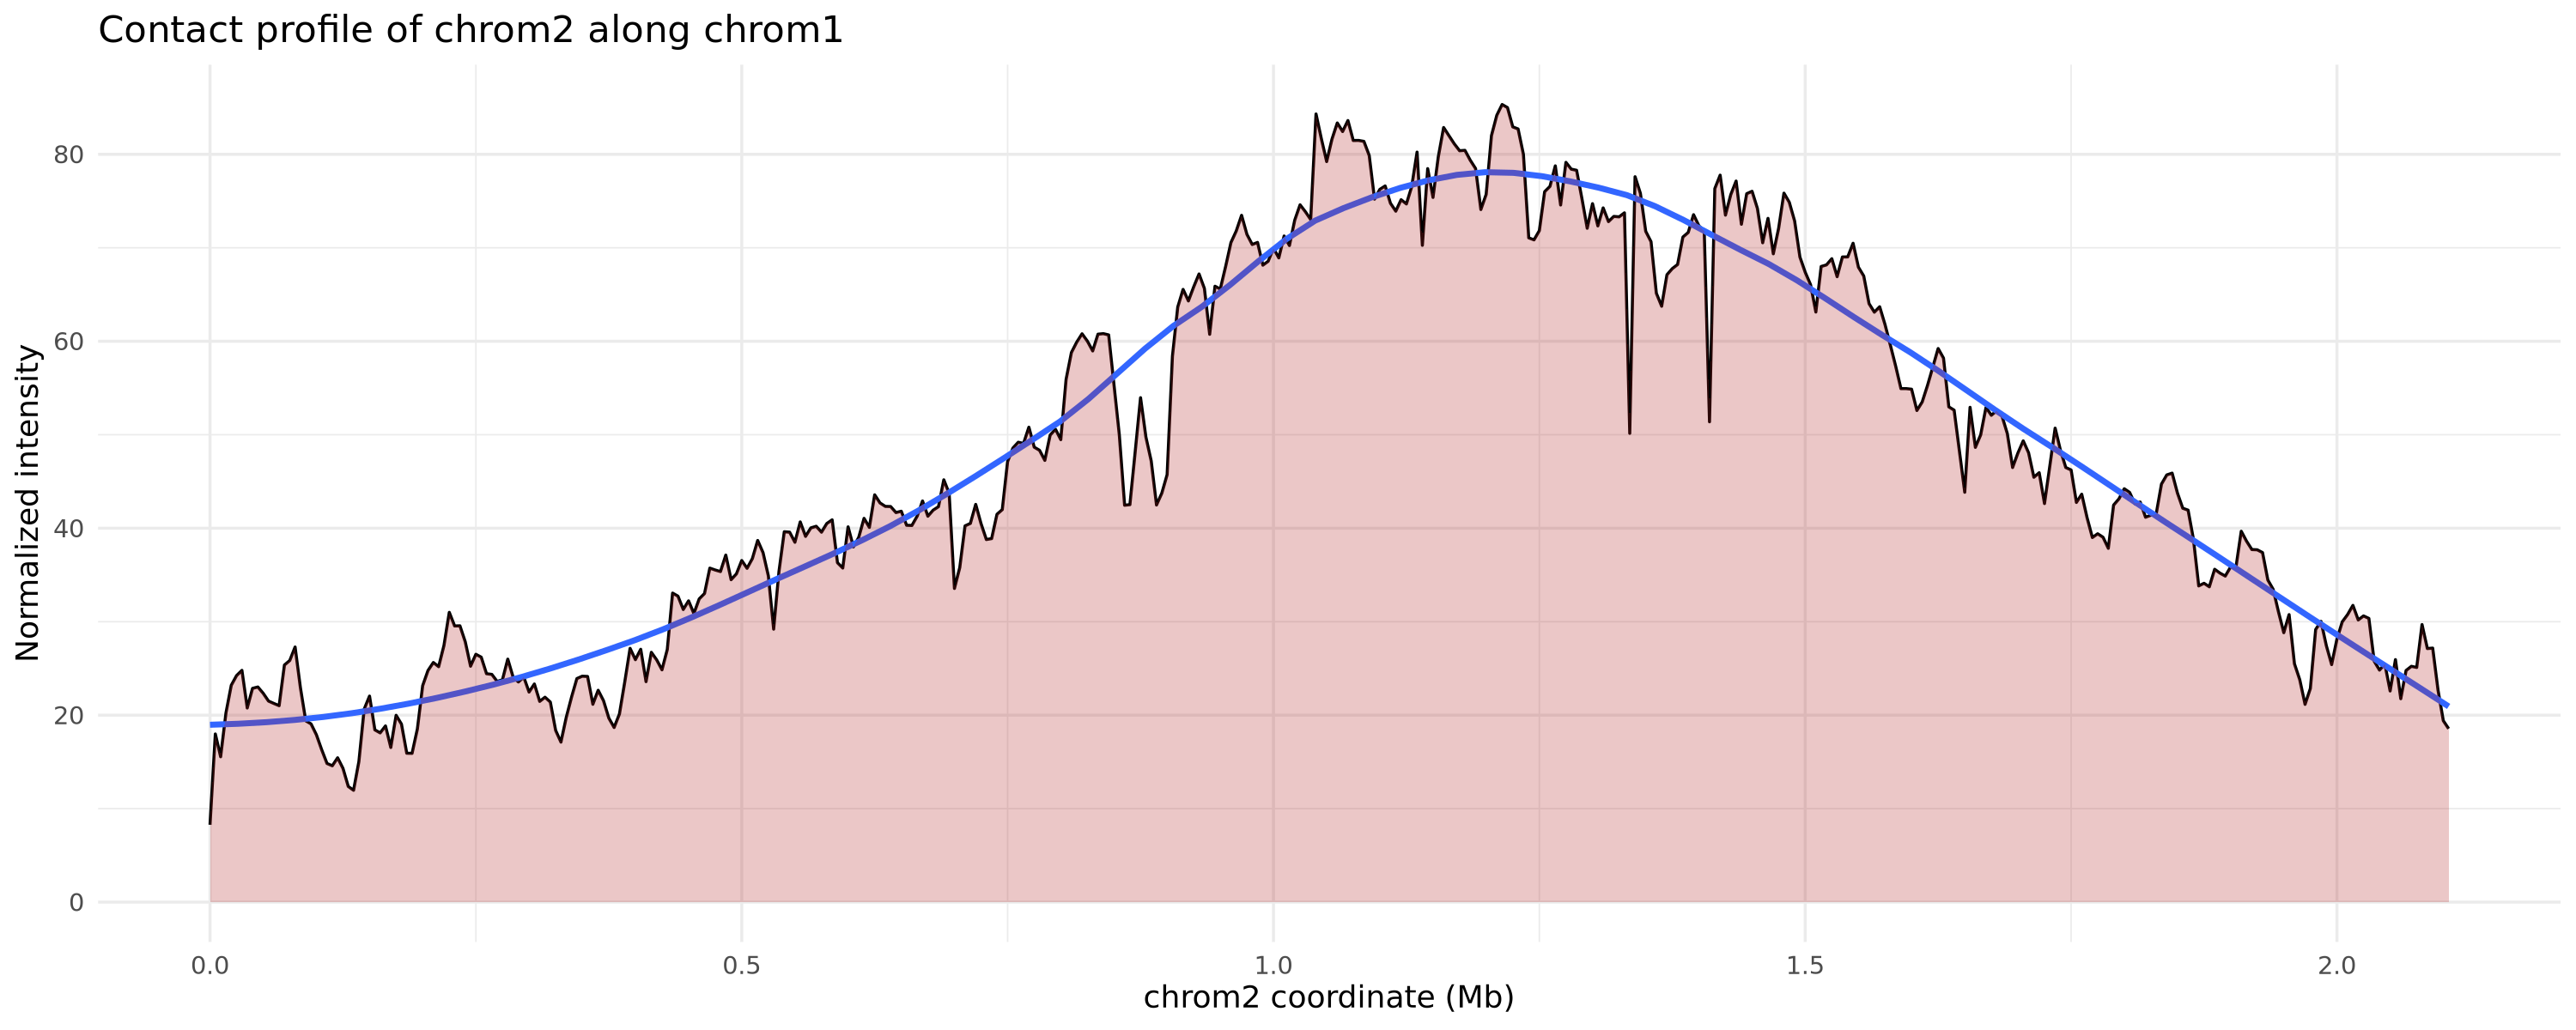

In [7]:
p.dims(15,6)
# Plot the contacts of every region in chrX (X axis) against chrY (Y axis)
profile_YX[, pos_Mb := start / 1e6]

thr <- mean(profile_YX$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_YX$end - profile_YX$start) / 1e3

#ggplot(profile_YX, aes(x = start, y = contacts)) +
ggplot(profile_YX, aes(x = pos_Mb, y = contacts_norm)) +
  geom_line(linewidth = 0.6) +
  geom_smooth(method = "loess", span = 0.5, se = FALSE) +
  geom_ribbon(
    aes(ymin = 0, ymax = contacts_norm),
    fill = "firebrick",
    alpha = 0.25
  ) +
  theme_minimal(base_size = 13) +
  labs(
    title = paste("Contact profile of", chrX_name, "along", chrY_name),
    #x = paste(chrY_name, "coordinate (bases)"),
    x = paste(chrX_name, "coordinate (Mb)"),
    y = "Normalized intensity"
    #y = paste("Contacts with", chrX_name),
    #subtitle = paste("Resolution:", bin_size_kb, "kb")
  )

`geom_smooth()` using formula = 'y ~ x'


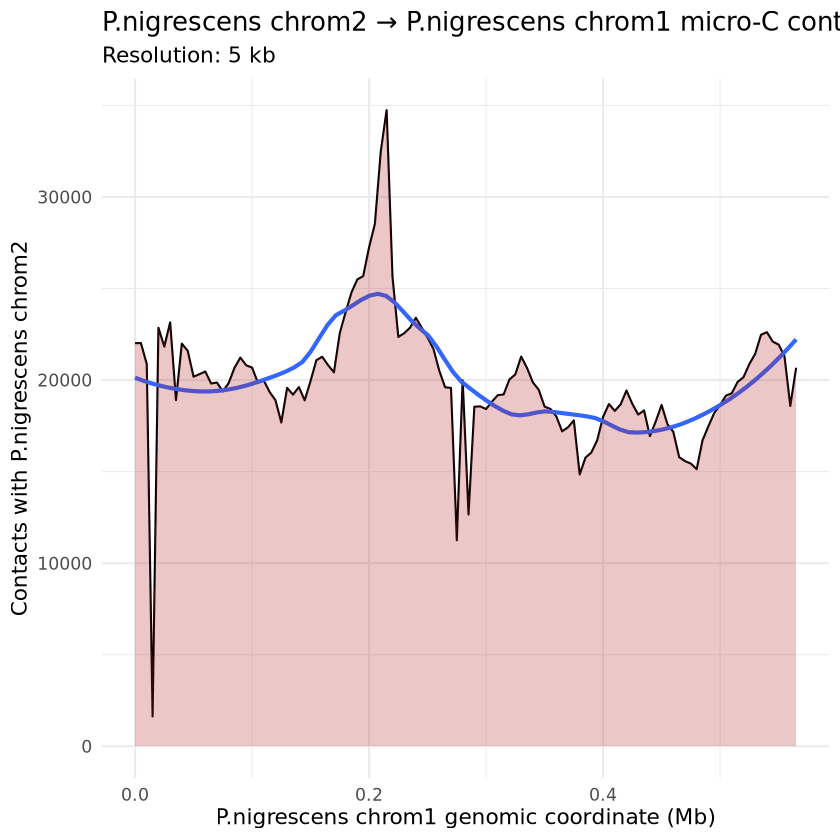

In [6]:
# Plot the contacts of every region in chrY (X axis) against chrX (Y axis)
profile_XY[, pos_Mb := start / 1e6]

thr <- mean(profile_XY$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_XY$end - profile_XY$start) / 1e3

#ggplot(profile_XY, aes(x = start, y = contacts)) +
ggplot(profile_XY, aes(x = pos_Mb, y = contacts)) +
  geom_line(linewidth = 0.6) +
  geom_smooth(method = "loess", span = 0.5, se = FALSE) +
  geom_ribbon(
    aes(ymin = 0, ymax = contacts),
    fill = "firebrick",
    alpha = 0.25
  ) +
  theme_minimal(base_size = 13) +
  labs(
    title = paste(chrX_name, "→", chrY_name, "micro-C contact profile"),
    #x = paste(chrY_name, "genomic coordinate (bases)"),
    x = paste(chrY_name, "genomic coordinate (Mb)"),
    y = paste("Contacts with", chrX_name),
    subtitle = paste("Resolution:", bin_size_kb, "kb")
  )

`geom_smooth()` using formula = 'y ~ x'


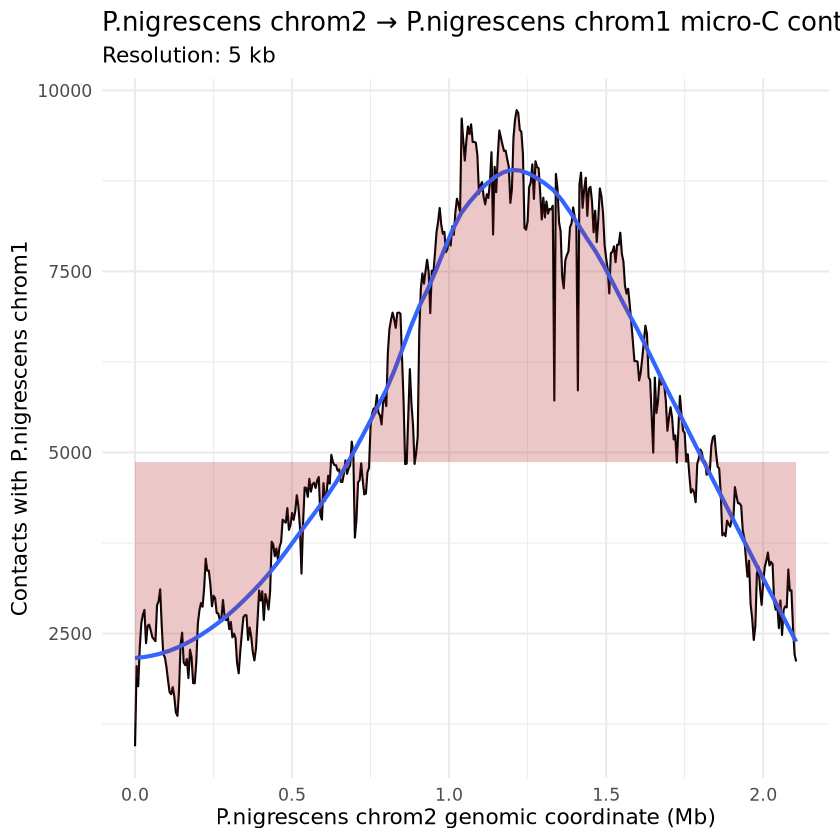

In [14]:
# Plot the contacts of every region in chrX (X axis) against chrY (Y axis)
profile_YX[, pos_Mb := start / 1e6]

thr <- mean(profile_YX$contacts, 0.95, na.rm = TRUE)
#thr <- quantile(profile_XY$contacts, 0.95, na.rm = TRUE)
bin_size_kb <- median(profile_YX$end - profile_YX$start) / 1e3

#ggplot(profile_YX, aes(x = start, y = contacts)) +
ggplot(profile_YX, aes(x = pos_Mb, y = contacts)) +
  geom_line(linewidth = 0.6) +
  geom_smooth(method = "loess", span = 0.5, se = FALSE) +
  geom_ribbon(
    aes(ymin = thr, ymax = contacts),
    fill = "firebrick",
    alpha = 0.25
  ) +
  theme_minimal(base_size = 13) +
  labs(
    title = paste(chrX_name, "→", chrY_name, "micro-C contact profile"),
    x = paste(chrX_name, "genomic coordinate (Mb)"),
    y = paste("Contacts with", chrY_name),
    subtitle = paste("Resolution:", bin_size_kb, "kb")
  )